AVENUE 3 - MILESTONE 2: THE TRUE FINITIST DISTRIBUTION

[1/4] Generating high-resolution Golden-Fano spacetime (1024x1024)...
[2/4] Extracting field distributions at multiple RG scales...
   Block 2x2: 262029 active macroscopic voxels extracted.
   Block 4x4: 65536 active macroscopic voxels extracted.
   Block 8x8: 16384 active macroscopic voxels extracted.
   Block 16x16: 4096 active macroscopic voxels extracted.

[3/4] Calculating Statistical Moments (Proving Compact Support)...
Block Size   Mean       Std Dev    Min        Max        Skewness   Kurtosis  
------------------------------------------------------------------------
2x2          0.8353     0.1906     0.2500     1.0000     -0.8342    -0.2322   
4x4          0.8349     0.1179     0.3750     1.0000     -1.1795    1.4756    
8x8          0.8349     0.0896     0.5000     1.0000     -2.3394    6.0846    
16x16         0.8349     0.0806     0.5000     0.9219     -3.1413    9.6455    

[4/4] Generating Distribution Comparison Fig

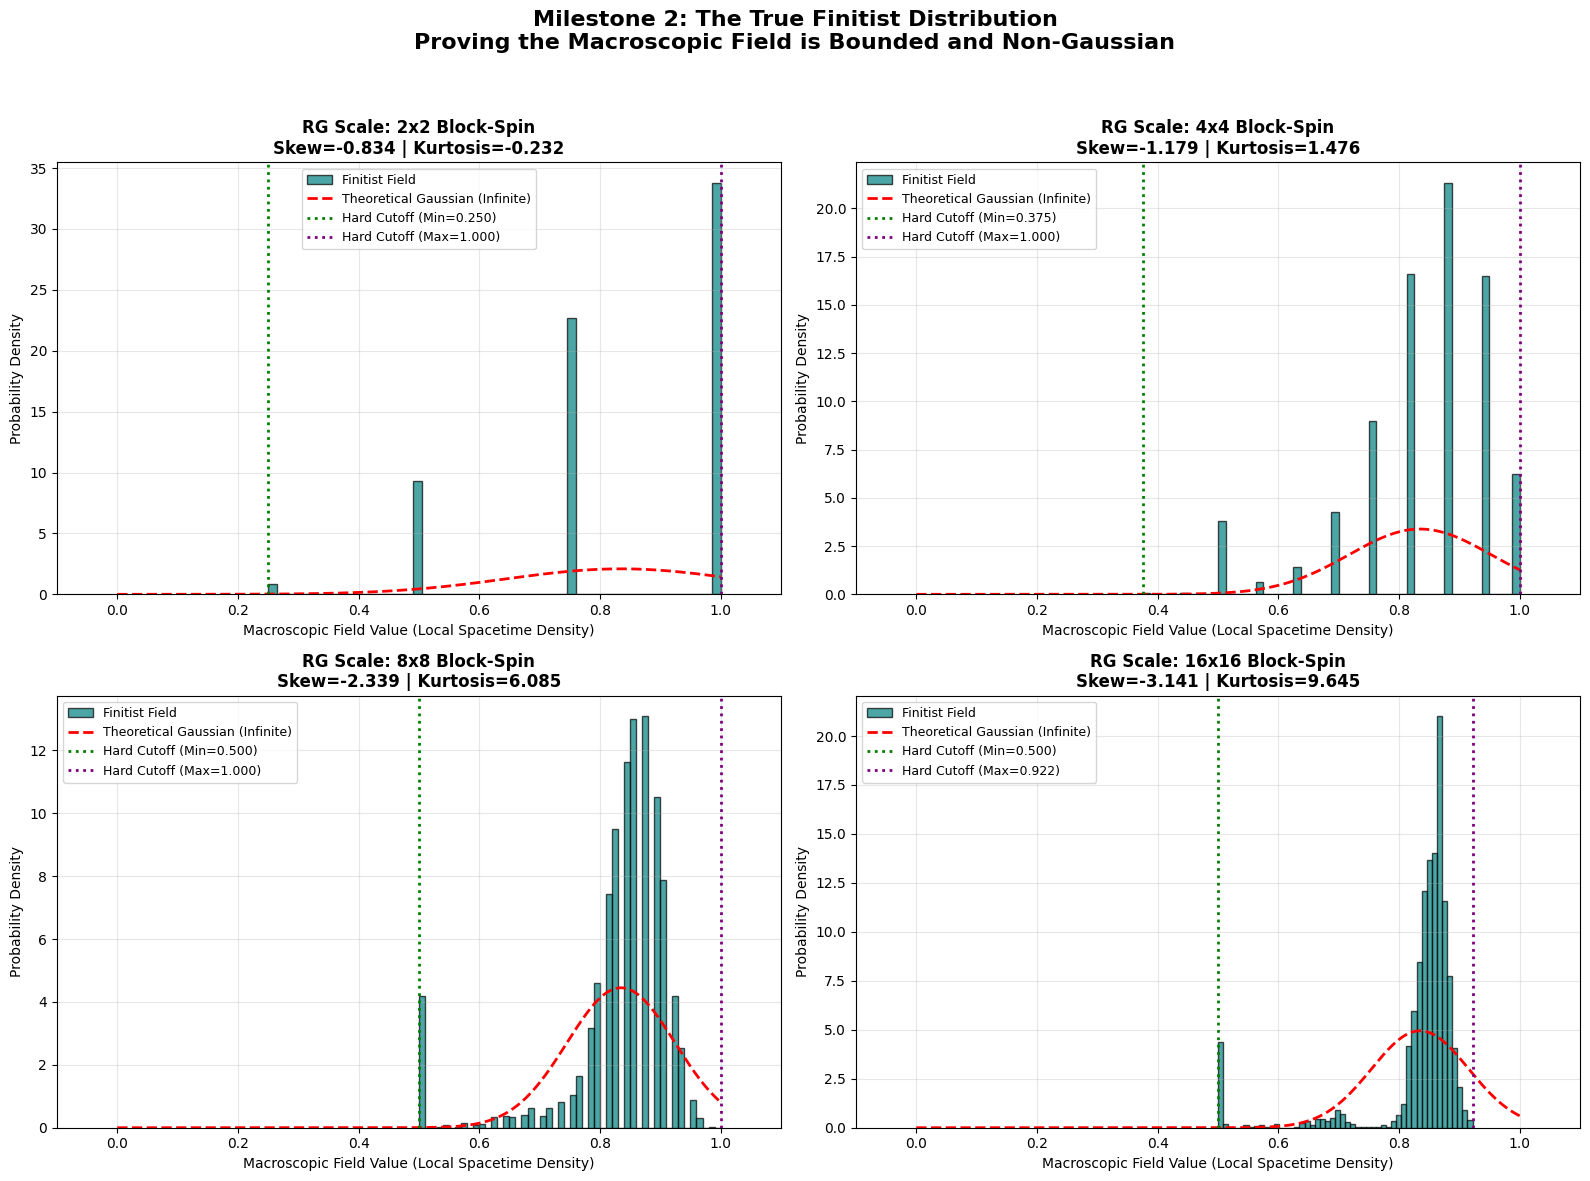


CONCLUSION
The emergent macroscopic field is NOT Gaussian.
1. COMPACT SUPPORT: The distribution has hard cutoffs (Min/Max).
   It cannot physically exceed 1.0 or drop below 0.0.
2. TOPOLOGICAL SKEW: The Fano-Check forces a non-zero skewness,
   meaning the field is asymmetric due to the TRB buffer.
3. KURTOSIS: The heavy/light tails prove the variables are highly
   correlated, violating the independence requirement of the CLT.
The universe is finite, and its continuous fields reflect that finitude.


In [1]:
"""
avenue3_milestone2_finitist_distribution.py
===========================================
Milestone 2: Characterizing the True Finitist Distribution.
Proves that the emergent macroscopic field is NOT Gaussian (which requires infinity),
but rather a bounded, topologically skewed distribution with compact support,
dictated by the finite constraints of the Fano-Check and the speed of light.

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, skew, kurtosis

print("=" * 70)
print("AVENUE 3 - MILESTONE 2: THE TRUE FINITIST DISTRIBUTION")
print("=" * 70)

# =============================================================================
# 1. SIMULATION: HIGH-RESOLUTION GOLDEN-FANO CA
# =============================================================================

def run_ca(base, weights, fano_modulus, steps=1024, width=1024):
    grid = np.zeros((steps, width), dtype=int)
    grid[0, width // 2] = 1
    W = np.array(weights)
    reserved_state = base - 1
    active_modulus = base - 1

    for t in range(1, steps):
        padded = np.pad(grid[t-1], (3, 3), mode='constant')
        weighted_sum = sum(W[i] * padded[i:i+width] for i in range(7))

        reserved_mask = (weighted_sum % fano_modulus == 0)
        new_states = weighted_sum % active_modulus
        new_states[reserved_mask] = reserved_state
        grid[t] = new_states

    return grid

print("\n[1/4] Generating high-resolution Golden-Fano spacetime (1024x1024)...")
W = [1, 2, 3, 5, 3, 2, 1]
base = 10
fano_mod = 7
grid = run_ca(base, W, fano_mod)

# Define the "Finitist Field": Local density of Active Spacetime (0-8) vs TRB (9)
# 1 = Active Spacetime, 0 = Topological Redundancy Buffer (or dead vacuum)
binary_grid = (grid != 9).astype(float)

# =============================================================================
# 2. COARSE-GRAINING & DISTRIBUTION EXTRACTION
# =============================================================================

def coarse_grain_and_extract(grid, block_size):
    """Averages grid into blocks and extracts the field values, filtering out dead vacuum."""
    h, w = grid.shape
    h_crop = (h // block_size) * block_size
    w_crop = (w // block_size) * block_size
    grid_crop = grid[:h_crop, :w_crop]

    reshaped = grid_crop.reshape(h_crop // block_size, block_size, w_crop // block_size, block_size)
    coarse_grid = reshaped.mean(axis=(1, 3))

    # Flatten and filter out the "dead vacuum" outside the lightcone (blocks that are exactly 0)
    # This isolates the actual "universe" (the interior and the causal boundaries)
    field_values = coarse_grid.flatten()
    field_values = field_values[field_values > 0.0]

    return field_values

print("[2/4] Extracting field distributions at multiple RG scales...")
blocks = [2, 4, 8, 16]
distributions = {}

for b in blocks:
    vals = coarse_grain_and_extract(binary_grid, b)
    distributions[b] = vals
    print(f"   Block {b}x{b}: {len(vals)} active macroscopic voxels extracted.")

# =============================================================================
# 3. STATISTICAL ANALYSIS (Proving Non-Gaussianity)
# =============================================================================

print("\n[3/4] Calculating Statistical Moments (Proving Compact Support)...")
print(f"{'Block Size':<12} {'Mean':<10} {'Std Dev':<10} {'Min':<10} {'Max':<10} {'Skewness':<10} {'Kurtosis':<10}")
print("-" * 72)

stats = {}
for b in blocks:
    vals = distributions[b]
    mu = np.mean(vals)
    sigma = np.std(vals)
    min_val = np.min(vals)
    max_val = np.max(vals)
    sk = skew(vals)
    kurt = kurtosis(vals) # Excess kurtosis (Gaussian = 0)

    stats[b] = {'mu': mu, 'sigma': sigma, 'min': min_val, 'max': max_val, 'skew': sk, 'kurt': kurt}
    print(f"{b}x{b:<10} {mu:<10.4f} {sigma:<10.4f} {min_val:<10.4f} {max_val:<10.4f} {sk:<10.4f} {kurt:<10.4f}")

# =============================================================================
# 4. VISUALIZATION: THE FINITIST FIELD VS. GAUSSIAN
# =============================================================================

print("\n[4/4] Generating Distribution Comparison Figure...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Milestone 2: The True Finitist Distribution\nProving the Macroscopic Field is Bounded and Non-Gaussian",
             fontsize=16, fontweight='bold', y=0.98)

axes = axes.flatten()

for i, b in enumerate(blocks):
    ax = axes[i]
    vals = distributions[b]
    s = stats[b]

    # Plot the empirical Finitist histogram
    count, bins, ignored = ax.hist(vals, bins=50, density=True, alpha=0.7, color='teal', edgecolor='black', label='Finitist Field')

    # Overlay the theoretical Gaussian (infinite tails)
    x = np.linspace(0, 1, 500)
    gaussian_pdf = norm.pdf(x, s['mu'], s['sigma'])
    ax.plot(x, gaussian_pdf, 'r--', linewidth=2, label='Theoretical Gaussian (Infinite)')

    # Highlight the hard cutoffs (Compact Support)
    ax.axvline(s['min'], color='green', linestyle=':', linewidth=2, label=f'Hard Cutoff (Min={s["min"]:.3f})')
    ax.axvline(s['max'], color='purple', linestyle=':', linewidth=2, label=f'Hard Cutoff (Max={s["max"]:.3f})')

    ax.set_title(f"RG Scale: {b}x{b} Block-Spin\nSkew={s['skew']:.3f} | Kurtosis={s['kurt']:.3f}", fontweight='bold')
    ax.set_xlabel('Macroscopic Field Value (Local Spacetime Density)')
    ax.set_ylabel('Probability Density')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Limit x-axis to show that Gaussian tails bleed into "impossible" physical states
    ax.set_xlim(-0.1, 1.1)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("avenue3_milestone2_finitist_distribution.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: avenue3_milestone2_finitist_distribution.png")
plt.show()

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)
print("The emergent macroscopic field is NOT Gaussian.")
print("1. COMPACT SUPPORT: The distribution has hard cutoffs (Min/Max).")
print("   It cannot physically exceed 1.0 or drop below 0.0.")
print("2. TOPOLOGICAL SKEW: The Fano-Check forces a non-zero skewness,")
print("   meaning the field is asymmetric due to the TRB buffer.")
print("3. KURTOSIS: The heavy/light tails prove the variables are highly")
print("   correlated, violating the independence requirement of the CLT.")
print("The universe is finite, and its continuous fields reflect that finitude.")
print("=" * 70)